In [2]:
'''data extraction'''
import pandas as pd
import numpy as np

f = open('kazuki_data.json')
kazuki_data = pd.read_json(f, orient='split')
f.close()
f = open('watara_data.json')
watara_data = pd.read_json(f, orient='split')
f.close()
f = open('yokoi_data.json')
yokoi_data = pd.read_json(f, orient='split')
f.close()

training = pd.concat([kazuki_data, yokoi_data.loc[0,:].iloc[:2000], yokoi_data.loc[1,:].iloc[:200]])
validation = pd.concat([watara_data, yokoi_data.loc[0,:].iloc[2000:], yokoi_data.loc[1,:].iloc[200:]])

t_healthy = training.loc[0]
t_cancer = training.loc[1]
v_healthy = validation.loc[0]
v_cancer = validation.loc[1]

m_t_healthy = t_healthy.shape[0]
m_t_cancer = t_cancer.shape[0]
m_v_healthy = v_healthy.shape[0]
m_v_cancer = v_cancer.shape[0]

n_mirnas = t_healthy.shape[1] #gets number of columns
miRNA_names_list = list(t_healthy.columns)

print("healthy training data")
print(t_healthy.shape)
print(t_healthy.head)
print("cancer training data")
print(t_cancer.shape)
print(t_cancer.head)
print("healthy validation data")
print(v_healthy.shape)
print(v_healthy.head)
print("cancer validation data")
print(v_cancer.shape)
print(v_cancer.head)

healthy training data
(6965, 2565)
<bound method NDFrame.head of     MIMAT0000062  MIMAT0000063  MIMAT0000064  MIMAT0000065  MIMAT0000066  \
0          3.700         3.669        -2.681         3.499        -2.681   
0         -4.018        -4.018        -4.018        -4.018        -4.018   
0          1.514         0.869         0.464        -0.987        -4.325   
0         -4.417        -4.417        -4.417        -1.036        -1.897   
0         -5.541         0.598        -5.281        -3.185         0.986   
..           ...           ...           ...           ...           ...   
0         -3.515         1.626         6.450        -3.515         1.136   
0         -3.160        -3.160        -3.160        -3.160        -3.160   
0         -3.717         0.509        -3.717        -3.717         1.166   
0         -2.374        -2.374         1.426         2.128         3.553   
0         -5.741         1.007        -5.741        -5.741        -5.741   

    MIMAT0000067  MIMA

In [3]:
Y = t_healthy.values
healthy_comp = np.zeros((n_mirnas, n_mirnas))
for a in range(n_mirnas):
    for b in range(n_mirnas):
        healthy_comp[a,b]=np.sum(Y[:,a] > Y[:,b])
healthy_comp = healthy_comp / m_t_healthy
print(healthy_comp)

[[0.         0.22368988 0.33725772 ... 0.13639627 0.41005025 0.42857143]
 [0.54515434 0.         0.57501795 ... 0.18880115 0.63460158 0.66245513]
 [0.29605169 0.20904523 0.         ... 0.11500359 0.4011486  0.42038765]
 ...
 [0.82311558 0.77774587 0.83833453 ... 0.         0.89375449 0.90193826]
 [0.19109835 0.14630294 0.20215363 ... 0.04005743 0.         0.25886576]
 [0.10150754 0.06661881 0.10911701 ... 0.03603733 0.15046662 0.        ]]


In [4]:
CONST_k = 0.95
stable_pairs = np.where((healthy_comp >= CONST_k) | (healthy_comp <= 1-CONST_k), 
                        1, 0)

In [5]:
print(stable_pairs.nonzero()[0].shape)

(2563428,)


In [6]:
Z = t_cancer.values
cancer_comp = np.zeros((n_mirnas, n_mirnas))
for a in range(n_mirnas):
    for b in range(n_mirnas):
        cancer_comp[a,b]=np.sum(Z[:,a] > Z[:,b])
cancer_comp = cancer_comp / m_t_cancer
print(cancer_comp)

[[0.    0.45  0.525 ... 0.505 0.67  0.635]
 [0.4   0.    0.505 ... 0.475 0.645 0.665]
 [0.29  0.31  0.    ... 0.38  0.52  0.49 ]
 ...
 [0.4   0.43  0.455 ... 0.    0.59  0.56 ]
 [0.15  0.13  0.18  ... 0.145 0.    0.205]
 [0.14  0.125 0.215 ... 0.23  0.385 0.   ]]


In [7]:
'''A,B are healthy/ovarian training'''
'''A,B are healthy/ovarian validation j bc X is used'''
A = v_healthy.values
healthy_comp = np.zeros((n_mirnas, n_mirnas))
for a in range(n_mirnas):
    for b in range(n_mirnas):
        healthy_comp[a,b]=np.sum(A[:,a] > A[:,b])
healthy_comp = healthy_comp / m_v_healthy
print(healthy_comp)

B = v_cancer.values
cancer_comp = np.zeros((n_mirnas, n_mirnas))
for a in range(n_mirnas):
    for b in range(n_mirnas):
        cancer_comp[a,b]=np.sum(B[:,a] > B[:,b])
cancer_comp = cancer_comp / m_v_cancer
print(cancer_comp)

[[0.         0.16666667 0.26801802 ... 0.10810811 0.3795045  0.38063063]
 [0.63626126 0.         0.64752252 ... 0.17567568 0.73198198 0.73873874]
 [0.31869369 0.1768018  0.         ... 0.12274775 0.40202703 0.40653153]
 ...
 [0.85810811 0.79617117 0.84459459 ... 0.         0.92004505 0.91891892]
 [0.10810811 0.05968468 0.11373874 ... 0.01801802 0.         0.13851351]
 [0.08333333 0.03490991 0.07545045 ... 0.02364865 0.12162162 0.        ]]
[[0.      0.33125 0.425   ... 0.5     0.61875 0.6125 ]
 [0.525   0.      0.55    ... 0.55    0.73125 0.725  ]
 [0.4     0.325   0.      ... 0.50625 0.68125 0.6625 ]
 ...
 [0.33125 0.29375 0.35625 ... 0.      0.5875  0.5375 ]
 [0.04375 0.025   0.05    ... 0.0625  0.      0.1125 ]
 [0.1     0.0875  0.08125 ... 0.1625  0.24375 0.     ]]


In [8]:
print(A.shape, B.shape)

(888, 2565) (160, 2565)


In [9]:
CONST_l = 0.75
stable_cancer_pairs = np.where((cancer_comp >= CONST_l) | (cancer_comp <= 1-CONST_l), 
                        1, 0)

In [10]:
identity_matrix = np.identity(n_mirnas,dtype=bool)
candidate_diagnostic_pairs = (((stable_pairs) & (stable_cancer_pairs)) & 
                            ((np.absolute(healthy_comp - cancer_comp)) > 0.5) &
                            (~identity_matrix))



In [11]:
'''
you might consider getting rid of redundnacy here.
check for correlation of clusters
'''
selected = candidate_diagnostic_pairs.nonzero()
# double check ts actually passes 
# for i in range(2):
#     for j in range(len(selected[i])):
#         print(miRNA_names_list[selected[i][j]] in og_set1 or miRNA_names_list[selected[i][j]] in og_set2)
# for i in range(len(selected[0])):
#     x = (t_healthy.iloc[:, selected[0][i]] > t_healthy.iloc[:, selected[1][i]]).sum()
#     print(f'mirna {selected[0][i]} and {selected[1][i]}')
print(selected[0].shape)
counts = np.bincount(selected[0])
for i, count in enumerate(counts):
    if count > 0:
        print(f"{i} occurs {count} times")


(485,)
9 occurs 2 times
38 occurs 1 times
45 occurs 1 times
71 occurs 1 times
135 occurs 7 times
148 occurs 1 times
328 occurs 1 times
334 occurs 1 times
344 occurs 1 times
345 occurs 4 times
374 occurs 1 times
412 occurs 3 times
461 occurs 1 times
489 occurs 1 times
514 occurs 1 times
535 occurs 1 times
542 occurs 14 times
566 occurs 2 times
589 occurs 1 times
595 occurs 2 times
616 occurs 1 times
626 occurs 1 times
630 occurs 1 times
673 occurs 2 times
688 occurs 2 times
694 occurs 1 times
696 occurs 1 times
704 occurs 1 times
713 occurs 12 times
714 occurs 5 times
731 occurs 7 times
736 occurs 1 times
745 occurs 18 times
762 occurs 4 times
765 occurs 1 times
785 occurs 1 times
791 occurs 3 times
810 occurs 5 times
815 occurs 1 times
829 occurs 1 times
836 occurs 2 times
872 occurs 5 times
879 occurs 2 times
913 occurs 1 times
926 occurs 1 times
931 occurs 1 times
933 occurs 9 times
939 occurs 1 times
944 occurs 1 times
957 occurs 1 times
965 occurs 16 times
966 occurs 1 times
970 oc

In [12]:
'''generate training input'''
pair_dict_training = {}
for i in range(len(selected[0])):
    _key = f"{selected[0][i]},{selected[1][i]}"
    _healthy_sect = Y[:,selected[0][i]]> Y[:,selected[1][i]]
    _cancer_sect = Z[:,selected[0][i]]> Z[:,selected[1][i]]
    pair_dict_training[_key] = np.concat((_healthy_sect, _cancer_sect))
_index = np.concat((np.zeros(m_t_healthy),np.ones(m_t_cancer)))
X_unshuffled = pd.DataFrame(pair_dict_training, index = _index)
X = X_unshuffled.sample(frac=1, random_state=42)
y = np.array(list(X.index))
X = X.reset_index().drop('index', axis=1)

In [13]:
'''generate validation input'''
pair_dict_validation = {}
for i in range(len(selected[0])):
    _key = f"{selected[0][i]},{selected[1][i]}"
    _healthy_sect = A[:,selected[0][i]]> A[:,selected[1][i]]
    _cancer_sect = B[:,selected[0][i]]> B[:,selected[1][i]]
    pair_dict_validation[_key] = np.concat((_healthy_sect, _cancer_sect))
_index = np.concat((np.zeros(m_v_healthy),np.ones(m_v_cancer)))
Xv_unshuffled = pd.DataFrame(pair_dict_validation, index = _index)
Xv = Xv_unshuffled.sample(frac=1, random_state=42)
yv = np.array(list(Xv.index))
Xv = Xv.reset_index().drop('index', axis=1)

In [14]:
X.shape, Xv.shape, y.shape, yv.shape

((7165, 485), (1048, 485), (7165,), (1048,))

In [144]:
Xv

,"81,542","81,1430","81,2193","135,688","135,1874","135,2167","135,2195","167,730","167,2289","167,2291","167,2401","167,2441","328,1666","328,2401","345,1676","430,1100","449,1676","461,2401","489,1477","514,1571","535,1676","542,81","573,2449","661,1557","667,1676","688,135","688,697","688,1499","688,1676","689,2419","697,688","697,2401","697,2441","702,2401","704,1676","713,931","713,1320","713,2195","730,167","730,1676",...,"2211,1889","2211,2324","2219,2203","2245,1571","2245,2391","2289,167","2289,1499","2289,1676","2291,167","2291,834","2291,1676","2316,1571","2324,1571","2324,2211","2357,1557","2391,732","2391,2245","2401,167","2401,328","2401,461","2401,697","2401,702","2401,765","2401,810","2401,1499","2401,1676","2401,1764","2401,1854","2411,1100","2419,689","2419,1764","2441,167","2441,697","2441,702","2441,1676","2443,1764","2449,573","2492,1676","2515,1571","2523,1676"
0,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,True,False,True,False,True,True,False,False,True,True,True,True,True,False,False,False,False,False,True,False,False,False,True,True,...,True,True,False,False,False,True,True,True,True,True,True,False,False,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True,False,True
1,True,False,True,True,False,False,True,False,True,True,False,True,False,False,False,True,True,False,False,True,False,False,True,False,False,False,True,True,True,True,False,False,False,False,False,True,True,False,True,True,...,True,True,True,True,True,False,False,False,False,False,False,True,True,False,False,True,False,True,True,True,True,True,True,False,True,True,True,True,True,False,False,False,True,False,False,True,False,False,True,False
2,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,True,False,True,False,True,False,True,True,True,True,False,False,True,False,False,True,False,...,True,True,False,True,False,True,False,False,False,True,False,True,False,False,False,True,True,True,True,True,False,True,True,False,True,False,True,True,False,False,True,True,False,True,False,True,True,False,False,False
3,True,True,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True,True,False,True,False,False,False,False,False,True,True,...,True,False,False,True,True,True,False,True,True,False,False,False,False,True,True,False,False,True,False,True,True,True,True,False,False,True,True,False,True,False,False,True,False,False,True,False,True,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,True,False,True,True,False,False,True,True,True,True,True,False,False,False,False,False,True,False,False,False,True,True,...,True,True,False,False,False,True,True,True,True,True,True,False,False,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,True,False,True,True,False,False,True,True,True,True,True,False,False,False,False,False,True,False,False,False,True,True,...,True,True,False,False,False,True,True,True,True,True,True,False,False,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True,False,True
1044,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,Tru

In [ ]:
yv

array([0., 1., 0., ..., 0., 1., 0.], shape=(1048,))

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# It's important to scale your data before applying PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
X_val_scaled = scaler.transform(Xv)

# Initialize PCA to retain 95% of the variance
pca = PCA(n_components=0.95)

# Fit and transform the training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform the validation data
X_val_pca = pca.transform(X_val_scaled)

# Now, train your SVM model on the PCA-transformed data
svc_pac = SVC(C=1.0, class_weight='balanced', kernel='linear')
rfe_pac = RFE(svc_pac, n_features_to_select=6)
rfe_pac.fit(X_train_pca, y)


,estimator,SVC(class_wei...rnel='linear')
,n_features_to_select,6
,step,1
,verbose,0
,importance_getter,'auto'
,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True


In [310]:
y_pac_pred = rfe_pac.decision_function(X_train_pca) > 0
cm_pac = confusion_matrix(y, y_pac_pred)
print(cm_pac)

[[6626  339]
 [  19  181]]


In [206]:
X_train_pca.shape

(7165, 141)

In [17]:
#logistic regression with lasso
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

from sklearn.svm import SVC
from sklearn.feature_selection import RFE, RFECV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import BaggingClassifier

import scipy.stats

import matplotlib.pyplot
# not importing scaling bc all of it is binary
OV_PREV=0.0004

In [16]:
C = [1.0,0.1,0.01]
class_weight = ['balanced', None]

graph_data = {'sensitivity': [], 'specificity': [], 'ppv': [], 'npv': []}
svc_graph_data = {'sensitivity': [], 'specificity': [], 'ppv': [], 'npv': []}

for c in range(len(C)):
    if(c==2):
        pass
    for key in graph_data:
        graph_data[key].append([])
        svc_graph_data[key].append([])
    for cw in range(len(class_weight)):
        svc_loop = SVC(C=C[c], class_weight=class_weight[cw], kernel='linear', random_state=67)
        svc_loop.fit(X,y)

        model_loop = RFE(estimator=svc_loop, n_features_to_select=6,step=1)
        model_loop.fit(X,y)
        yv_pred_loop = model_loop.decision_function(Xv)
        yv_prediction_values_loop = np.array(yv_pred_loop)
        
        cmv_loop = confusion_matrix(yv, yv_prediction_values_loop>0)
        sensitivityv_loop = cmv_loop[1,1]/(cmv_loop[1,1]+cmv_loop[1,0])
        specificityv_loop = (cmv_loop[0,0]/(cmv_loop[0,0]+cmv_loop[0,1]))

        ppv_loop = (sensitivityv_loop*OV_PREV) / ((sensitivityv_loop*OV_PREV) + (1-specificityv_loop) * (1-OV_PREV))
        npv_loop = (specificityv_loop * (1-OV_PREV) / ((specificityv_loop*(1-OV_PREV)) + (1-sensitivityv_loop) * OV_PREV))
        
        graph_data['sensitivity'][c].append(sensitivityv_loop)
        graph_data['specificity'][c].append(specificityv_loop)
        graph_data['ppv'][c].append(ppv_loop)
        graph_data['npv'][c].append(npv_loop)
        
        # ----- cmv for the svc
        # yv_prediction_values_loop = svc_loop.predict(Xv) > 0.5
        # cmv_loop = confusion_matrix(yv, yv_prediction_values_loop>0)
        # sensitivityv_loop = cmv_loop[1,1]/(cmv_loop[1,1]+cmv_loop[1,0])
        # specificityv_loop = (cmv_loop[0,0]/(cmv_loop[0,0]+cmv_loop[0,1]))

        # ppv_loop = (sensitivityv_loop*OV_PREV) / ((sensitivityv_loop*OV_PREV) + (1-specificityv_loop) * (1-OV_PREV))
        # npv_loop = (specificityv_loop * (1-OV_PREV) / ((specificityv_loop*(1-OV_PREV)) + (1-sensitivityv_loop) * OV_PREV))

        # svc_graph_data['sensitivity'][c].append(sensitivityv_loop)
        # svc_graph_data['specificity'][c].append(specificityv_loop)
        # svc_graph_data['ppv'][c].append(ppv_loop)
        # svc_graph_data['npv'][c].append(npv_loop)
graph_data

{'sensitivity': [[np.float64(0.99375), np.float64(0.95)],
  [np.float64(0.975), np.float64(0.88125)],
  [np.float64(1.0), np.float64(0.85625)]],
 'specificity': [[np.float64(0.9662162162162162),
   np.float64(0.9662162162162162)],
  [np.float64(0.9662162162162162), np.float64(0.9684684684684685)],
  [np.float64(0.9673423423423423), np.float64(0.9684684684684685)]],
 'ppv': [[np.float64(0.011633770563772168), np.float64(0.01112729114565197)],
  [np.float64(0.011416771498421591), np.float64(0.011060066101755996)],
  [np.float64(0.012104854210117349), np.float64(0.01074967818826887)]],
 'npv': [[np.float64(0.9999974115587335), np.float64(0.9999792928450624)],
  [np.float64(0.9999896463153335), np.float64(0.9999509362692847)],
  [np.float64(1.0), np.float64(0.9999406076762938)]]}

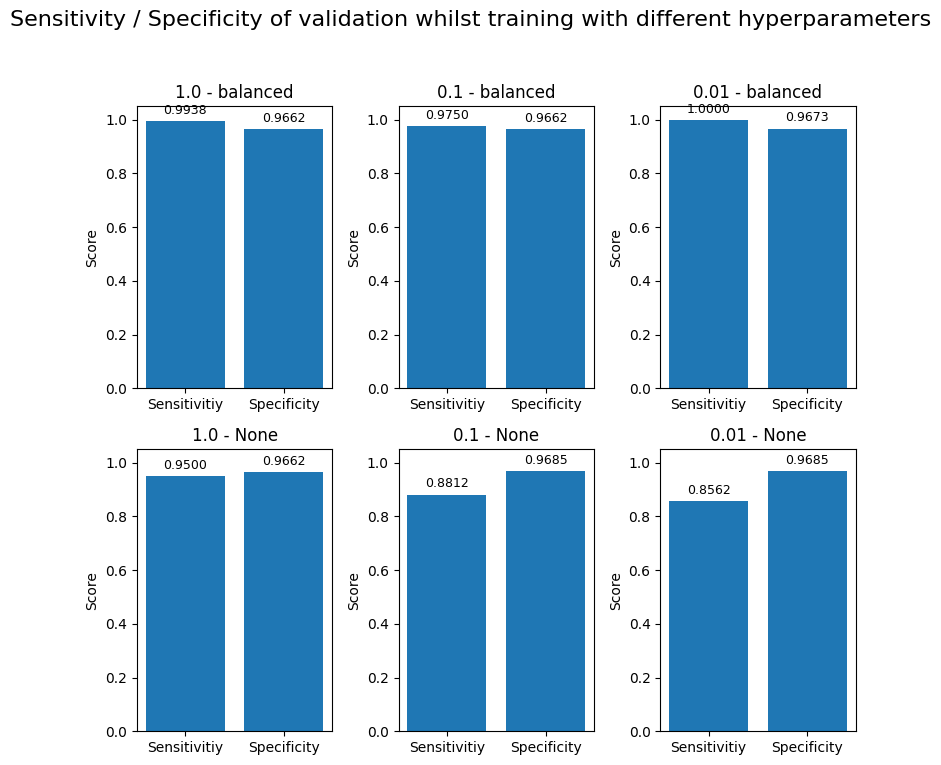

In [21]:
graph_sensitivity = graph_data['sensitivity']
graph_specificity = graph_data['specificity']
graph_rows = 2
graph_cols = 3
fig, axes = plt.subplots(graph_rows,graph_cols, figsize=(8,8))
graph_C_labels = [str(i) for i in C]
graph_balanced_labels = ['balanced', 'None']

# Loop through the 2x3 grid to create the subplots
for r in range(graph_rows): # r=0 (Test A), r=1 (Test B)
    for c in range(graph_cols): # c=0 (Scenario 1), c=1 (Scenario 2), c=2 (Scenario 3)
        ax = axes[r, c]

        # Data for the current subplot: (c is the group index, r is the sub-group index)
        current_sen = graph_sensitivity[c][r]
        current_spec = graph_specificity[c][r]
        metrics = [current_sen, current_spec]
        
        # Positions for the bars
        x = np.arange(2)
        
        # Create the bar chart
        bars = ax.bar(x, metrics)
        
        # Set titles and labels
        ax.set_title(f'{graph_C_labels[c]} - {graph_balanced_labels[r]}')
        ax.set_xticks(x)
        ax.set_xticklabels(['Sensitivitiy', 'Specificity'])
        ax.set_ylabel('Score')
        
        # Set y-axis limit and format y-ticks
        ax.set_ylim(0, 1.05)
        ax.set_yticks(np.arange(0, 1.01, 0.2))
        ax.tick_params(axis='x', rotation=0)
        
        # Add the score on top of the bars
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

fig.suptitle('Sensitivity / Specificity of validation whilst training with different hyperparameters', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle




In [300]:
C = [0.01]
class_weight = [{0:1,1:i} for i in range (70,1,-15)]

graph_data = {'sensitivity': [], 'specificity': [], 'ppv': [], 'npv': []}
svc_graph_data = {'sensitivity': [], 'specificity': [], 'ppv': [], 'npv': []}

for c in range(len(C)):
    if(c==2):
        pass
    for key in graph_data:
        graph_data[key].append([])
        svc_graph_data[key].append([])
    for cw in range(len(class_weight)):
        svc_loop = SVC(C=C[c], class_weight=class_weight[cw], kernel='linear')
        svc_loop.fit(X,y)

        model_loop = RFE(estimator=svc_loop, n_features_to_select=6,step=1)
        model_loop.fit(X,y)
        yv_pred_loop = model_loop.decision_function(Xv)
        yv_prediction_values_loop = np.array(yv_pred_loop)
        
        cmv_loop = confusion_matrix(yv, yv_prediction_values_loop>0)
        sensitivityv_loop = cmv_loop[1,1]/(cmv_loop[1,1]+cmv_loop[1,0])
        specificityv_loop = (cmv_loop[0,0]/(cmv_loop[0,0]+cmv_loop[0,1]))

        # ppv_loop = (sensitivityv_loop*OV_PREV) / ((sensitivityv_loop*OV_PREV) + (1-specificityv_loop) * (1-OV_PREV))
        # npv_loop = (specificityv_loop * (1-OV_PREV) / ((specificityv_loop*(1-OV_PREV)) + (1-sensitivityv_loop) * OV_PREV))
        
        graph_data['sensitivity'][c].append(sensitivityv_loop)
        graph_data['specificity'][c].append(specificityv_loop)
        # graph_data['ppv'][c].append(ppv_loop)
        # graph_data['npv'][c].append(npv_loop)
        
        # ----- cmv for the svc
        # yv_prediction_values_loop = svc_loop.predict(Xv) > 0.5
        # cmv_loop = confusion_matrix(yv, yv_prediction_values_loop>0)
        # sensitivityv_loop = cmv_loop[1,1]/(cmv_loop[1,1]+cmv_loop[1,0])
        # specificityv_loop = (cmv_loop[0,0]/(cmv_loop[0,0]+cmv_loop[0,1]))

        # ppv_loop = (sensitivityv_loop*OV_PREV) / ((sensitivityv_loop*OV_PREV) + (1-specificityv_loop) * (1-OV_PREV))
        # npv_loop = (specificityv_loop * (1-OV_PREV) / ((specificityv_loop*(1-OV_PREV)) + (1-sensitivityv_loop) * OV_PREV))

        # svc_graph_data['sensitivity'][c].append(sensitivityv_loop)
        # svc_graph_data['specificity'][c].append(specificityv_loop)
        # svc_graph_data['ppv'][c].append(ppv_loop)
        # svc_graph_data['npv'][c].append(npv_loop)
graph_data

{'sensitivity': [[np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(0.975)]],
 'specificity': [[np.float64(0.9650900900900901),
   np.float64(0.9650900900900901),
   np.float64(0.9650900900900901),
   np.float64(0.9673423423423423),
   np.float64(0.9650900900900901)]],
 'ppv': [[]],
 'npv': [[]]}

In [38]:
svc_loop = SVC(C=0.01, class_weight={0:1, 1:25}, kernel='linear')
svc_loop.fit(X,y)

model_loop = RFE(estimator=svc_loop, n_features_to_select=2,step=1)
model_loop.fit(X,y)
yv_pred_loop = model_loop.decision_function(Xv)
yv_prediction_values_loop = np.array(yv_pred_loop)

cmv_loop = confusion_matrix(yv, yv_prediction_values_loop>0)
sensitivityv_loop = cmv_loop[1,1]/(cmv_loop[1,1]+cmv_loop[1,0])
specificityv_loop = (cmv_loop[0,0]/(cmv_loop[0,0]+cmv_loop[0,1]))

ppv_loop = (sensitivityv_loop*OV_PREV) / ((sensitivityv_loop*OV_PREV) + (1-specificityv_loop) * (1-OV_PREV))
npv_loop = (specificityv_loop * (1-OV_PREV) / ((specificityv_loop*(1-OV_PREV)) + (1-sensitivityv_loop) * OV_PREV))
        

In [22]:
graph_data = {}
num_of_features_cycle = range(2,7)

for i in num_of_features_cycle:
    svc_loop = SVC(C=0.01, class_weight='balanced', kernel='linear')
    svc_loop.fit(X,y)

    model_loop = RFE(estimator=svc_loop, n_features_to_select=i,step=1)
    model_loop.fit(X,y)
    yv_pred_loop = model_loop.decision_function(Xv)
    yv_prediction_values_loop = np.array(yv_pred_loop)

    cmv_loop = confusion_matrix(yv, yv_prediction_values_loop>0)
    sensitivityv_loop = cmv_loop[1,1]/(cmv_loop[1,1]+cmv_loop[1,0])
    specificityv_loop = (cmv_loop[0,0]/(cmv_loop[0,0]+cmv_loop[0,1]))

    graph_data[i] = [sensitivityv_loop, specificityv_loop]

In [32]:
graph_data

array({2: [np.float64(0.99375), np.float64(0.9594594594594594)], 3: [np.float64(0.99375), np.float64(0.9594594594594594)], 4: [np.float64(1.0), np.float64(0.9594594594594594)], 5: [np.float64(1.0), np.float64(0.9650900900900901)], 6: [np.float64(1.0), np.float64(0.9673423423423423)]},
      dtype=object)

In [33]:
graph_data = {2: [np.float64(0.99375), np.float64(0.9594594594594594)], 3: [np.float64(0.99375), np.float64(0.9594594594594594)], 4: [np.float64(1.0), np.float64(0.9594594594594594)], 5: [np.float64(1.0), np.float64(0.9650900900900901)], 6: [np.float64(1.0), np.float64(0.9673423423423423)]}

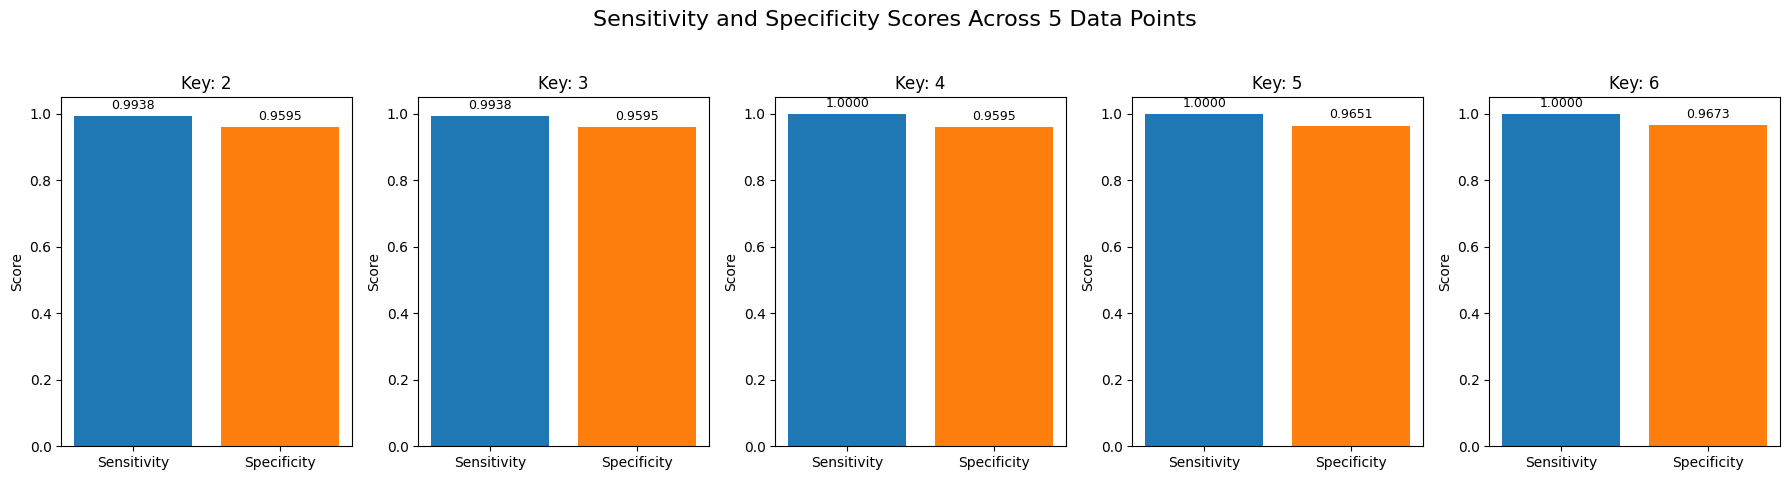

In [34]:
# Determine the layout
rows = 1
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(18, 5)) 

# Labels and colors
bar_labels = ['Sensitivity', 'Specificity']
bar_colors = ['#1f77b4', '#ff7f0e'] # Blue and orange
subplot_keys = sorted(graph_data.keys()) # Sort the keys (2, 3, 4, 5, 6) to ensure order

# Loop through the 5 subplots
for i, key in enumerate(subplot_keys):
    # Access the correct axis object. When rows=1, axes is a 1D array.
    ax = axes[i] 

    # Data for the current subplot
    current_metrics = graph_data[key]
    current_sen = current_metrics[0]
    current_spec = current_metrics[1]
    metrics = [current_sen, current_spec]
    
    # Positions for the bars
    x = np.arange(len(bar_labels))
    
    # Create the bar chart
    bars = ax.bar(x, metrics, color=bar_colors)
    
    # Set titles and labels
    ax.set_title(f'Key: {key}', fontsize=12) # Use the key as the title
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels)
    ax.set_ylabel('Score')
    
    # Set y-axis limit and format y-ticks
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.01, 0.2)) # Set major ticks at 0.2 intervals
    ax.tick_params(axis='x', rotation=0)
    
    # Add the score on top of the bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

fig.suptitle('Sensitivity and Specificity Scores Across 5 Data Points', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle


In [23]:
print("Confusion Matrix: \n", cmv_loop)
print(f"Sensitivity (Recall): {sensitivityv_loop:.4f}")
print(f"Specificity: {specificityv_loop:.4f}")
print(f"ppv: {ppv_loop:.4f}")
print(f"npv: {npv_loop:.4f}")
print(classification_report(yv,yv_prediction_values_loop>0))


Confusion Matrix: 
 [[859  29]
 [  0 160]]
Sensitivity (Recall): 1.0000
Specificity: 0.9673
ppv: 0.0107
npv: 0.9999
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98       888
         1.0       0.85      1.00      0.92       160

    accuracy                           0.97      1048
   macro avg       0.92      0.98      0.95      1048
weighted avg       0.98      0.97      0.97      1048



In [39]:
select_indices = np.where(model_loop.ranking_ - 1 == 0)
X.columns[select_indices]

Index(['791,2241', '2427,745'], dtype='object')

In [40]:
[miRNA_names_list[i] for i in [791,2241,2427,745]]

['MIMAT0005929', 'MIMAT0027500', 'MIMAT0027686', 'MIMAT0005880']

In [ ]:
fig,ax = plt.subplots(nrows=2, ncols=len(2), sharey=True)
graph_titles = [['sensitivity', 'specificity'], ['ppv', 'npv']]
for i, row in enumerate(ax):
    for j, col in enumerate(row):
        title = graph_titles[i][j]
        col.bar()

In [280]:
svc = SVC(C=0.01,kernel='linear',class_weight=None)
svc.fit(X,y)


,C,0.01
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
'''sklearn.svm.SVC(kernel = 'poly', degree=3), #default
sklearn.svm.SVC(kernel = 'rbf'),
sklearn.svm.SVC(kernel = 'sigmoid')'''
param_grid = {'C': scipy.stats.expon(scale=100), 
               'class_weight':['balanced',None]}
RandomSearchCV = RandomizedSearchCV(estimator=svc, param_distributions=param_grid, 
                                    n_iter=50, random_state=42)
RandomSearchCV.fit(X,y)
best_params = RandomSearchCV.get_params()
print(best_params) #i just changed the og svc to the params given

In [37]:
model = RFE(estimator=svc, n_features_to_select=2, step=1)
y_pred = model.decision_function(X)
y_prediction_values = np.array(y_pred)
cm = confusion_matrix(y, y_prediction_values>0)
sensitivity = cm[1,1]/(cm[1,1]+cm[1,0])
specificity = (cm[0,0]/(cm[0,0]+cm[0,1]))
print("Confusion Matrix: \n", cm)
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
ppv = (sensitivity*OV_PREV) / ((sensitivity*OV_PREV) + (1-specificity) * (1-OV_PREV))
npv = (specificity * (1-OV_PREV) / ((specificity*(1-OV_PREV)) + (1-sensitivity) * OV_PREV))
print(f"ppv: {ppv:.4f}")
print(f"npv: {specificity:.4f}")

print(classification_report(y,y_prediction_values>0))


NameError: name 'svc' is not defined

In [275]:
from sklearn.metrics import roc_curve

scores = model.decision_function(X)
fpr, tpr, thresholds = roc_curve(y, scores)

# remove infinities from thresholds
fpr, tpr, thresholds = roc_curve(y, scores)
mask = np.isfinite(thresholds)
fpr = fpr[mask]
tpr = tpr[mask]
thresholds = thresholds[mask]

# pick threshold for >= 0.99 specificity
target_spec = 0.992
idx = np.where(1 - fpr >= target_spec)[0][-1]
best_threshold = thresholds[idx]
print(best_threshold)
y_pred = model.decision_function(X)
y_prediction_values = np.array(y_pred)
cm = confusion_matrix(y, y_prediction_values>best_threshold)
sensitivity = cm[1,1]/(cm[1,1]+cm[1,0])
specificity = (cm[0,0]/(cm[0,0]+cm[0,1]))
print("Confusion Matrix: \n", cm)
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
ppv = (sensitivity*OV_PREV) / ((sensitivity*OV_PREV) + (1-specificity) * (1-OV_PREV))
npv = (specificity * (1-OV_PREV) / ((specificity*(1-OV_PREV)) + (1-sensitivity) * OV_PREV))
print(f"ppv: {ppv:.4f}")
print(f"npv: {specificity:.4f}")


0.7999999999999999
Confusion Matrix: 
 [[6952   13]
 [  47  153]]
Sensitivity (Recall): 0.7650
Specificity: 0.9981
ppv: 0.1409
npv: 0.9981


In [279]:
yv_pred = model.decision_function(Xv)
yv_prediction_values = np.array(yv_pred)
cmv = confusion_matrix(yv, yv_prediction_values > best_threshold)
sensitivityv = cmv[1,1]/(cmv[1,1]+cmv[1,0])
specificityv = (cmv[0,0]/(cmv[0,0]+cmv[0,1]))

print("Confusion Matrix: \n", cmv)
print(f"Sensitivity (Recall): {sensitivityv:.4f}")
print(f"Specificity: {specificityv:.4f}")
ppvv = (sensitivityv*OV_PREV) / ((sensitivityv*OV_PREV) + (1-specificityv) * (1-OV_PREV))
npvv = (specificityv * (1-OV_PREV) / ((specificityv*(1-OV_PREV)) + (1-sensitivityv) * OV_PREV))
print(f"ppv: {ppvv:.4f}")
print(f"npv: {npvv:.4f}")
print(classification_report(yv,yv_prediction_values>0))

Confusion Matrix: 
 [[860  28]
 [ 34 126]]
Sensitivity (Recall): 0.7875
Specificity: 0.9685
ppv: 0.0099
npv: 0.9999
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.97       888
         1.0       0.82      0.79      0.81       160

    accuracy                           0.94      1048
   macro avg       0.89      0.88      0.89      1048
weighted avg       0.94      0.94      0.94      1048



In [100]:
bag_model = BaggingClassifier(estimator=model, n_estimators = 10, random_state=42)
bag_model.fit(X,y)

bag_model.estimators_[0].ranking_


array([359,  79, 268, 154, 220, 251, 118, 159, 177, 271, 201, 411,   1,
         3, 469, 343,  25, 282, 281,  26, 184, 351, 459, 420,  36,  97,
       463, 344, 246, 307, 133, 475, 386, 399, 354, 387, 264, 283, 192,
       403, 137, 162, 418, 439,  71, 291,  48, 232,  34,  65, 231,   5,
       286, 301, 252, 378,   6, 297, 323,   9,  63, 276,  47,  84, 350,
       345, 417,  30, 158,  49, 114, 476, 207,  82,  13, 452, 330, 228,
       328, 238,  66, 385, 108, 461, 257, 144, 265, 258, 267, 401,  16,
       260, 167, 136, 451, 186, 163, 214, 255,   1, 369, 432, 470, 465,
       464,  80,   1,  55,  46, 319, 208, 170, 109,  22, 150, 174, 298,
       412,   8, 410, 341, 315, 152, 364, 182, 400, 263, 235,  27, 172,
        53,  10, 185, 122, 324,  21,  89,  96, 219,  31, 142,  94, 128,
       380, 449, 444, 340, 126, 373,  35, 262, 454, 347, 237, 374, 110,
        69,  72, 338, 195, 306, 275, 352, 356, 248, 367, 157, 171,  17,
        77,  12,  85, 138, 280,  29, 389, 365,  58, 366, 203, 34

In [38]:
avg_ranking = np.concatenate(tuple([np.reshape(bag_model.estimators_[i].ranking_, (-1,1)) for i in range(10)]), axis=1)
avg_ranking

array([[359, 219, 368, ..., 227, 169, 369],
       [103, 395, 298, ..., 407, 263, 324],
       [268,  86, 292, ..., 321, 253, 316],
       ...,
       [462, 113,  98, ...,  25, 133, 454],
       [388, 433, 227, ..., 192, 242, 223],
       [421, 131, 153, ..., 149, 252, 465]], shape=(485, 10))

In [39]:
avg_ranking = np.sum(avg_ranking, axis=1) / 10

array([329.4, 303.1, 230.8, 228.5, 183.3, 345.4, 370.1, 238.9, 302.8,
       152.6, 293.5, 332.2, 143.1, 160. , 312.3, 261.8, 214.8, 333.6,
       347.5, 169.3, 355.3, 271.9, 319. , 258.3,  49.6, 239.7, 372.9,
       258.1, 273.1, 265.8, 143.1, 326.2, 315.8, 306.8, 257.6, 212.4,
       205.4, 265.5, 315.1, 286.8, 318. , 327.5, 290.3, 290.8,  68.3,
       343.3, 139.6, 299.6,  18.2, 208.4, 236.3,  85.6, 366.3, 249.1,
       295.8, 285.8,  73.5, 343.9, 237.6,  76.9, 150.9, 287.2,  39.3,
       339.4, 208.2, 331.7, 290.9, 100.6, 164.6, 173.3, 166.3, 285.7,
       279.8, 204.9, 235.9, 243.4, 272.8, 101.1, 149.2, 265.9,  63.1,
       294.4, 236.9, 363.9, 342.2, 294.2, 278.9, 331.5, 156.5, 358.5,
        29.7, 206. , 335.4, 301.7, 357. , 149.2, 115.4, 203.3, 158.3,
        10.7, 235. , 263.1, 284. , 288.3, 340.9, 297.3, 105.7,  16.2,
        27.3, 262. , 246.6, 335.4, 300.8,  47.5, 193.5, 295.6, 329.3,
       271.5, 149. , 336.6, 300.2, 241.2, 283.9, 342.2, 319. , 195.9,
       317.2, 247.5,

In [43]:
y_pred = bag_model.decision_function(X)
y_prediction_values = np.array(y_pred)
cm = confusion_matrix(y, y_prediction_values>0)
sensitivity = cm[1,1]/(cm[1,1]+cm[0,1])
specificity = (cm[0,0]/(cm[0,0]+cm[1,0]))
print("Confusion Matrix: \n", cm)
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y,y_prediction_values>0))

Confusion Matrix: 
 [[6960    5]
 [  12  188]]
Sensitivity (Recall): 0.9741
Specificity: 0.9983
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6965
         1.0       0.97      0.94      0.96       200

    accuracy                           1.00      7165
   macro avg       0.99      0.97      0.98      7165
weighted avg       1.00      1.00      1.00      7165



In [116]:
yv_pred = model.decision_function(Xv)
yv_prediction_values = np.array(yv_pred)
cmv = confusion_matrix(yv, yv_prediction_values>0)
sensitivityv = cmv[1,1]/(cmv[1,1]+cmv[0,1])
specificityv = (cmv[0,0]/(cmv[0,0]+cmv[1,0]))
print("Confusion Matrix: \n", cmv)
print(f"Sensitivity (Recall): {sensitivityv:.4f}")
print(f"Specificity: {specificityv:.4f}")
print(classification_report(yv,yv_prediction_values>0))

Confusion Matrix: 
 [[863  25]
 [ 18 142]]
Sensitivity (Recall): 0.8503
Specificity: 0.9796
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98       888
         1.0       0.85      0.89      0.87       160

    accuracy                           0.96      1048
   macro avg       0.91      0.93      0.92      1048
weighted avg       0.96      0.96      0.96      1048

